# Autocorrelation Analysis (ACF & PACF)

We perform **Autocorrelation Function (ACF)** and **Partial Autocorrelation Function (PACF)** analysis on:

| Dataset | Sampling | Source |
|---------|----------|--------|
| **Dow Jones** | Monthly closing index | `monthly-closings-of-the-dowjones.csv` |
| **S&P 500** | Daily open prices (2016) | `sp500.csv` |
| **Lake Erie** | Monthly water levels (1921–1970) | `monthly-lake-erie-levels-1921-19.csv` |
| **Monthly Milk Production** | Monthly lbs/cow (1962–1975) | `monthly-milk-production-pounds-p.csv` |

### For each dataset:
1. Compute ACF up to lag 50
2. Compute PACF up to lag 50
3. Plot both with 95% confidence bands
4. Identify significant lags and periodicity patterns
5. Provide numerical summary and interpretation

In [ ]:
# ============================================================
# PROCESS IDENTIFICATION
# ============================================================
import os
print(f"Process ID (PID): {os.getpid()}")


In [ ]:
# ============================================================
# NOTEBOOK TIMER — START
# ============================================================
import time as _timer_module
_NOTEBOOK_START_TIME = _timer_module.time()
print(f"Notebook execution started at: {_timer_module.strftime('%Y-%m-%d %H:%M:%S')}")


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import acf, pacf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── Global dark-theme style ───────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0f0f1a',
    'axes.facecolor':    '#1a1a2e',
    'axes.edgecolor':    '#3a3a5c',
    'axes.labelcolor':   '#e0e0ff',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.color':       '#a0a0cc',
    'ytick.color':       '#a0a0cc',
    'grid.color':        '#2a2a4a',
    'grid.linestyle':    '--',
    'grid.alpha':        0.6,
    'text.color':        '#e0e0ff',
    'font.family':       'DejaVu Sans',
    'lines.linewidth':   1.6,
})

PALETTE = {
    'Dow Jones':               '#7c83fd',
    'S&P 500':                 '#fc5c7d',
    'Lake Erie':               '#43e97b',
    'Monthly Milk Production': '#f7971e',
}

print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── Load datasets ─────────────────────────────────────────────────────────────
def load_dataset(path):
    df = pd.read_csv(path)
    return df.iloc[:, 0], df.iloc[:, 1].astype(float).values

datasets = {
    'Dow Jones': {
        'path':        '../content/monthly-closings-of-the-dowjones.csv',
        'period_unit': 'months',
        'expected_period': 12,
    },
    'S&P 500': {
        'path':        '../content/sp500.csv',
        'period_unit': 'trading days',
        'expected_period': 21,  # ~1 trading month
    },
    'Lake Erie': {
        'path':        '../content/monthly-lake-erie-levels-1921-19.csv',
        'period_unit': 'months',
        'expected_period': 12,
    },
    'Monthly Milk Production': {
        'path':        '../content/monthly-milk-production-pounds-p.csv',
        'period_unit': 'months',
        'expected_period': 12,
    },
}

for name, meta in datasets.items():
    idx, vals = load_dataset(meta['path'])
    meta['index']  = idx
    meta['values'] = vals
    print(f'{name:30s} → {len(vals):4d} observations')

print('\nAll datasets loaded ✓')

Dow Jones                      →  291 observations
S&P 500                        →  251 observations
Lake Erie                      →  600 observations
Monthly Milk Production        →  168 observations

All datasets loaded ✓


In [3]:
# ── ACF / PACF Computation ────────────────────────────────────────────────────
MAX_LAG = 50

def compute_acf_pacf(values, nlags=MAX_LAG):
    """
    Compute ACF and PACF with 95% confidence intervals.
    Returns dict with arrays and summary statistics.
    """
    N = len(values)
    nlags_actual = min(nlags, N // 2 - 1)  # statsmodels requirement

    # ACF with confidence intervals
    acf_vals, acf_confint = acf(values, nlags=nlags_actual, alpha=0.05,
                                fft=True)
    # PACF with confidence intervals
    pacf_vals, pacf_confint = pacf(values, nlags=nlags_actual, alpha=0.05,
                                   method='ywm')

    lags = np.arange(nlags_actual + 1)

    # 95% significance threshold (Bartlett: ±1.96/√N)
    sig_threshold = 1.96 / np.sqrt(N)

    # Significant ACF lags (excluding lag 0 which is always 1.0)
    sig_acf_lags = [int(l) for l in lags[1:] if abs(acf_vals[l]) > sig_threshold]

    # Significant PACF lags (excluding lag 0)
    sig_pacf_lags = [int(l) for l in lags[1:] if abs(pacf_vals[l]) > sig_threshold]

    # Detect periodicity: find local peaks in ACF
    periodic_lags = []
    for i in range(2, len(acf_vals) - 1):
        if (acf_vals[i] > acf_vals[i-1] and
            acf_vals[i] > acf_vals[i+1] and
            acf_vals[i] > sig_threshold):
            periodic_lags.append(int(i))

    # First lag where ACF drops below significance
    decorrelation_lag = None
    for l in range(1, len(acf_vals)):
        if abs(acf_vals[l]) < sig_threshold:
            decorrelation_lag = int(l)
            break

    # ACF at lag 1 (persistence measure)
    acf_lag1 = acf_vals[1] if len(acf_vals) > 1 else None

    # Ljung-Box-ish: sum of squared ACF (measure of overall autocorrelation)
    acf_energy = float(np.sum(acf_vals[1:] ** 2))

    return {
        'acf_vals':         acf_vals,
        'acf_confint':      acf_confint,
        'pacf_vals':        pacf_vals,
        'pacf_confint':     pacf_confint,
        'lags':             lags,
        'sig_threshold':    sig_threshold,
        'sig_acf_lags':     sig_acf_lags,
        'sig_pacf_lags':    sig_pacf_lags,
        'periodic_lags':    periodic_lags,
        'decorrelation_lag': decorrelation_lag,
        'acf_lag1':         acf_lag1,
        'acf_energy':       acf_energy,
        'N':                N,
        'nlags':            nlags_actual,
    }

for name, meta in datasets.items():
    meta['corr'] = compute_acf_pacf(meta['values'])

print('ACF & PACF computed for all datasets ✓')

ACF & PACF computed for all datasets ✓


In [4]:
# ── Printed numerical results ─────────────────────────────────────────────────
SEP  = '═' * 78
SEP2 = '─' * 78

for name, meta in datasets.items():
    c   = meta['corr']
    pu  = meta['period_unit']
    acf_v  = c['acf_vals']
    pacf_v = c['pacf_vals']

    print(f'\n{SEP}')
    print(f'  {name.upper()}  —  Autocorrelation Summary')
    print(f'  N = {c["N"]}  |  Max lag = {c["nlags"]}  |  95% threshold = ±{c["sig_threshold"]:.6f}')
    print(SEP)

    # ── ACF values at key lags ────────────────────────────────────────────
    print(f'\n  ACF VALUES AT KEY LAGS:')
    print(f'  {"Lag":>5}  {"ACF":>10}  {"Significant?":>14}  {"Interpretation"}')
    print(f'  {SEP2}')
    key_lags = sorted(set([1, 2, 3, 4, 5, 6, 10, 12, 15, 20, 24, 25, 30, 36, 40, 48, 50])
                      & set(range(len(acf_v))))
    for lag in key_lags:
        val  = acf_v[lag]
        sig  = '  YES ***' if abs(val) > c['sig_threshold'] else '  no'
        note = ''
        if lag == 1:
            note = f'  (persistence = {val:.6f})'
        elif lag in c['periodic_lags']:
            note = '  ← periodic peak'
        print(f'  {lag:>5}  {val:>10.6f}  {sig:>14}{note}')

    # ── PACF values at key lags ───────────────────────────────────────────
    print(f'\n  PACF VALUES AT KEY LAGS:')
    print(f'  {"Lag":>5}  {"PACF":>10}  {"Significant?":>14}')
    print(f'  {SEP2}')
    key_lags_pacf = sorted(set([1, 2, 3, 4, 5, 6, 10, 12, 15, 20, 24, 25, 30, 36, 40, 48, 50])
                           & set(range(len(pacf_v))))
    for lag in key_lags_pacf:
        val = pacf_v[lag]
        sig = '  YES ***' if abs(val) > c['sig_threshold'] else '  no'
        print(f'  {lag:>5}  {val:>10.6f}  {sig:>14}')

    # ── Summary metrics ───────────────────────────────────────────────────
    print(f'\n  SUMMARY METRICS:')
    print(f'  {SEP2}')
    print(f'  ACF at lag 1 (persistence):       {c["acf_lag1"]:.6f}')
    print(f'  Decorrelation lag (ACF < threshold): {c["decorrelation_lag"]} {pu}' if c['decorrelation_lag'] else '  Decorrelation lag: Never (within computed lags)')
    print(f'  ACF energy (Σ ACF²):              {c["acf_energy"]:.6f}')
    print(f'  # Significant ACF lags:           {len(c["sig_acf_lags"])} / {c["nlags"]}')
    print(f'  # Significant PACF lags:          {len(c["sig_pacf_lags"])} / {c["nlags"]}')
    print(f'  Significant ACF lags:             {c["sig_acf_lags"]}')
    print(f'  Significant PACF lags:            {c["sig_pacf_lags"]}')
    print(f'  ACF periodic peaks at lags:       {c["periodic_lags"] if c["periodic_lags"] else "None detected"}')

    # ── Interpretation ────────────────────────────────────────────────────
    print(f'\n  INTERPRETATION:')
    print(f'  {SEP2}')
    if c['acf_lag1'] > 0.9:
        print('  • Very high lag-1 ACF (>0.9) → strong short-term persistence / trend')
    elif c['acf_lag1'] > 0.7:
        print('  • High lag-1 ACF (>0.7) → moderate-to-strong persistence')
    elif c['acf_lag1'] > 0.4:
        print('  • Moderate lag-1 ACF → some short-term memory')
    else:
        print('  • Low lag-1 ACF → weak persistence')

    if c['decorrelation_lag'] is None:
        print(f'  • ACF never drops below significance within {c["nlags"]} lags → very long memory / trend')
    elif c['decorrelation_lag'] > 20:
        print(f'  • Slow ACF decay (decorrelation at lag {c["decorrelation_lag"]}) → long-range dependence')
    else:
        print(f'  • Moderate ACF decay (decorrelation at lag {c["decorrelation_lag"]})')

    if c['periodic_lags']:
        gaps = [c['periodic_lags'][i] - c['periodic_lags'][i-1]
                for i in range(1, len(c['periodic_lags']))]
        if gaps:
            avg_gap = np.mean(gaps)
            print(f'  • Periodic peaks detected at lags {c["periodic_lags"]} → avg spacing ≈ {avg_gap:.1f} {pu}')
        else:
            print(f'  • Single periodic peak at lag {c["periodic_lags"][0]}')
    else:
        print('  • No clear periodic peaks in ACF → likely aperiodic / trend-dominated')

    if len(c['sig_pacf_lags']) <= 3:
        print(f'  • PACF cuts off after {max(c["sig_pacf_lags"]) if c["sig_pacf_lags"] else 0} lags → suggests AR({len(c["sig_pacf_lags"])}) model')
    elif len(c['sig_pacf_lags']) <= 8:
        print(f'  • PACF has {len(c["sig_pacf_lags"])} significant lags → moderate AR order')
    else:
        print(f'  • PACF has {len(c["sig_pacf_lags"])} significant lags → slow PACF decay, consider differencing or ARIMA')

print(f'\n{SEP}')
print('  INTERPRETATION GUIDE')
print('  • ACF decays slowly + PACF cuts off     → AR(p) process')
print('  • ACF cuts off + PACF decays slowly      → MA(q) process')
print('  • Both decay slowly                      → ARMA or needs differencing')
print('  • ACF peaks at regular intervals         → seasonal component present')
print(f'{SEP}')


══════════════════════════════════════════════════════════════════════════════
  DOW JONES  —  Autocorrelation Summary
  N = 291  |  Max lag = 50  |  95% threshold = ±0.114897
══════════════════════════════════════════════════════════════════════════════

  ACF VALUES AT KEY LAGS:
    Lag         ACF    Significant?  Interpretation
  ──────────────────────────────────────────────────────────────────────────────
      1    0.973730         YES ***  (persistence = 0.973730)
      2    0.943488         YES ***
      3    0.909767         YES ***
      4    0.876494         YES ***
      5    0.844394         YES ***
      6    0.814027         YES ***
     10    0.727298         YES ***
     12    0.688557         YES ***
     15    0.611504         YES ***
     20    0.478382         YES ***
     24    0.388262         YES ***
     25    0.360374         YES ***
     30    0.243433         YES ***
     36    0.105424              no
     40   -0.012177              no
     48   -0.14648

In [5]:
# ── Full ACF value tables (all lags 1–50) ─────────────────────────────────────
for name, meta in datasets.items():
    c = meta['corr']
    pu = meta['period_unit']
    print(f'\n{"═"*60}')
    print(f'  {name.upper()}  —  Complete ACF & PACF Values (lag 1 to {c["nlags"]})')
    print(f'{"═"*60}')
    print(f'  {"Lag":>4}  {"ACF":>10}  {"PACF":>10}  {"ACF sig?":>9}  {"PACF sig?":>9}')
    print(f'  {"─"*50}')
    for lag in range(1, c['nlags'] + 1):
        a_val = c['acf_vals'][lag]
        p_val = c['pacf_vals'][lag]
        a_sig = '***' if abs(a_val) > c['sig_threshold'] else ''
        p_sig = '***' if abs(p_val) > c['sig_threshold'] else ''
        print(f'  {lag:>4}  {a_val:>10.6f}  {p_val:>10.6f}  {a_sig:>9}  {p_sig:>9}')
    print()


════════════════════════════════════════════════════════════
  DOW JONES  —  Complete ACF & PACF Values (lag 1 to 50)
════════════════════════════════════════════════════════════
   Lag         ACF        PACF   ACF sig?  PACF sig?
  ──────────────────────────────────────────────────
     1    0.973730    0.973730        ***        ***
     2    0.943488   -0.089913        ***           
     3    0.909767   -0.077542        ***           
     4    0.876494    0.000250        ***           
     5    0.844394    0.007366        ***           
     6    0.814027    0.011475        ***           
     7    0.789463    0.089569        ***           
     8    0.764473   -0.040944        ***           
     9    0.745210    0.088059        ***           
    10    0.727298    0.005407        ***           
    11    0.707931   -0.052028        ***           
    12    0.688557   -0.002144        ***           
    13    0.664503   -0.087843        ***           
    14    0.639809   -0.0

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOTTING HELPER — ACF/PACF panels for a single dataset
# ══════════════════════════════════════════════════════════════════════════════

def plot_acf_pacf(name, meta, save_prefix):
    c     = meta['corr']
    color = PALETTE[name]
    pu    = meta['period_unit']
    lags  = c['lags']
    acf_v = c['acf_vals']
    pacf_v = c['pacf_vals']
    sig_t = c['sig_threshold']

    fig = plt.figure(figsize=(16, 13))
    gs  = gridspec.GridSpec(3, 1, height_ratios=[0.8, 1.1, 1.1], hspace=0.35)
    fig.suptitle(f'{name}  —  ACF & PACF Analysis',
                 fontsize=17, fontweight='bold', color='#e0e0ff', y=0.98)

    # ── (a) Time series ──────────────────────────────────────────────────
    ax0 = fig.add_subplot(gs[0])
    ax0.plot(meta['values'], color=color, alpha=0.9, linewidth=1.2)
    ax0.fill_between(range(len(meta['values'])), meta['values'],
                     alpha=0.12, color=color)
    ax0.set_title('(a) Time Series', fontsize=13)
    ax0.set_xlabel('Sample Index')
    ax0.set_ylabel('Value')
    ax0.grid(True)

    # ── (b) ACF ──────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[1])

    # Stem plot (skip lag 0)
    markerline, stemlines, baseline = ax1.stem(
        lags[1:], acf_v[1:], linefmt='-', markerfmt='o', basefmt=' ')
    plt.setp(stemlines, color=color, linewidth=1.8, alpha=0.85)
    plt.setp(markerline, color=color, markersize=5, zorder=5)

    # 95% confidence band
    ax1.axhspan(-sig_t, sig_t, color='white', alpha=0.08,
                label=f'95% CI (±{sig_t:.4f})')
    ax1.axhline(sig_t,  color='#ff4444', linestyle='--', linewidth=0.9, alpha=0.6)
    ax1.axhline(-sig_t, color='#ff4444', linestyle='--', linewidth=0.9, alpha=0.6)
    ax1.axhline(0, color='white', linewidth=0.5, alpha=0.4)

    # Mark periodic peaks
    for pl in c['periodic_lags']:
        ax1.annotate(f'lag {pl}', xy=(pl, acf_v[pl]),
                     xytext=(0, 15), textcoords='offset points',
                     fontsize=8, color='#ffd700', ha='center',
                     arrowprops=dict(arrowstyle='->', color='#ffd700', lw=0.9))

    ax1.set_title(f'(b) Autocorrelation Function (ACF)  —  up to lag {c["nlags"]}', fontsize=13)
    ax1.set_xlabel(f'Lag ({pu})')
    ax1.set_ylabel('ACF')
    ax1.legend(fontsize=9, framealpha=0.4, loc='upper right')
    ax1.grid(True)

    # Info box
    info = (f'ACF(1) = {c["acf_lag1"]:.4f}\n'
            f'Decorr lag: {c["decorrelation_lag"] or ">" + str(c["nlags"])}\n'
            f'Sig lags: {len(c["sig_acf_lags"])}/{c["nlags"]}\n'
            f'Periodic peaks: {c["periodic_lags"] or "None"}')
    ax1.text(0.98, 0.05, info, transform=ax1.transAxes,
             fontsize=9, va='bottom', ha='right',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#0f0f1a',
                       edgecolor=color, alpha=0.9),
             color='#e0e0ff')

    # ── (c) PACF ─────────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[2])

    markerline, stemlines, baseline = ax2.stem(
        lags[1:], pacf_v[1:], linefmt='-', markerfmt='o', basefmt=' ')
    plt.setp(stemlines, color=color, linewidth=1.8, alpha=0.85)
    plt.setp(markerline, color=color, markersize=5, zorder=5)

    ax2.axhspan(-sig_t, sig_t, color='white', alpha=0.08,
                label=f'95% CI (±{sig_t:.4f})')
    ax2.axhline(sig_t,  color='#ff4444', linestyle='--', linewidth=0.9, alpha=0.6)
    ax2.axhline(-sig_t, color='#ff4444', linestyle='--', linewidth=0.9, alpha=0.6)
    ax2.axhline(0, color='white', linewidth=0.5, alpha=0.4)

    # Mark significant PACF lags
    for sl in c['sig_pacf_lags'][:5]:  # annotate top 5
        ax2.annotate(f'{pacf_v[sl]:.3f}', xy=(sl, pacf_v[sl]),
                     xytext=(0, -18 if pacf_v[sl] > 0 else 15),
                     textcoords='offset points',
                     fontsize=8, color='#ffd700', ha='center')

    ax2.set_title(f'(c) Partial Autocorrelation Function (PACF)  —  up to lag {c["nlags"]}', fontsize=13)
    ax2.set_xlabel(f'Lag ({pu})')
    ax2.set_ylabel('PACF')
    ax2.legend(fontsize=9, framealpha=0.4, loc='upper right')
    ax2.grid(True)

    # Info box
    info2 = f'Sig PACF lags: {len(c["sig_pacf_lags"])}/{c["nlags"]}\nLags: {c["sig_pacf_lags"][:10]}'
    ax2.text(0.98, 0.05, info2, transform=ax2.transAxes,
             fontsize=9, va='bottom', ha='right',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#0f0f1a',
                       edgecolor=color, alpha=0.9),
             color='#e0e0ff')

    plt.savefig(f'{save_prefix}.png', dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f'Saved → {save_prefix}.png\n')

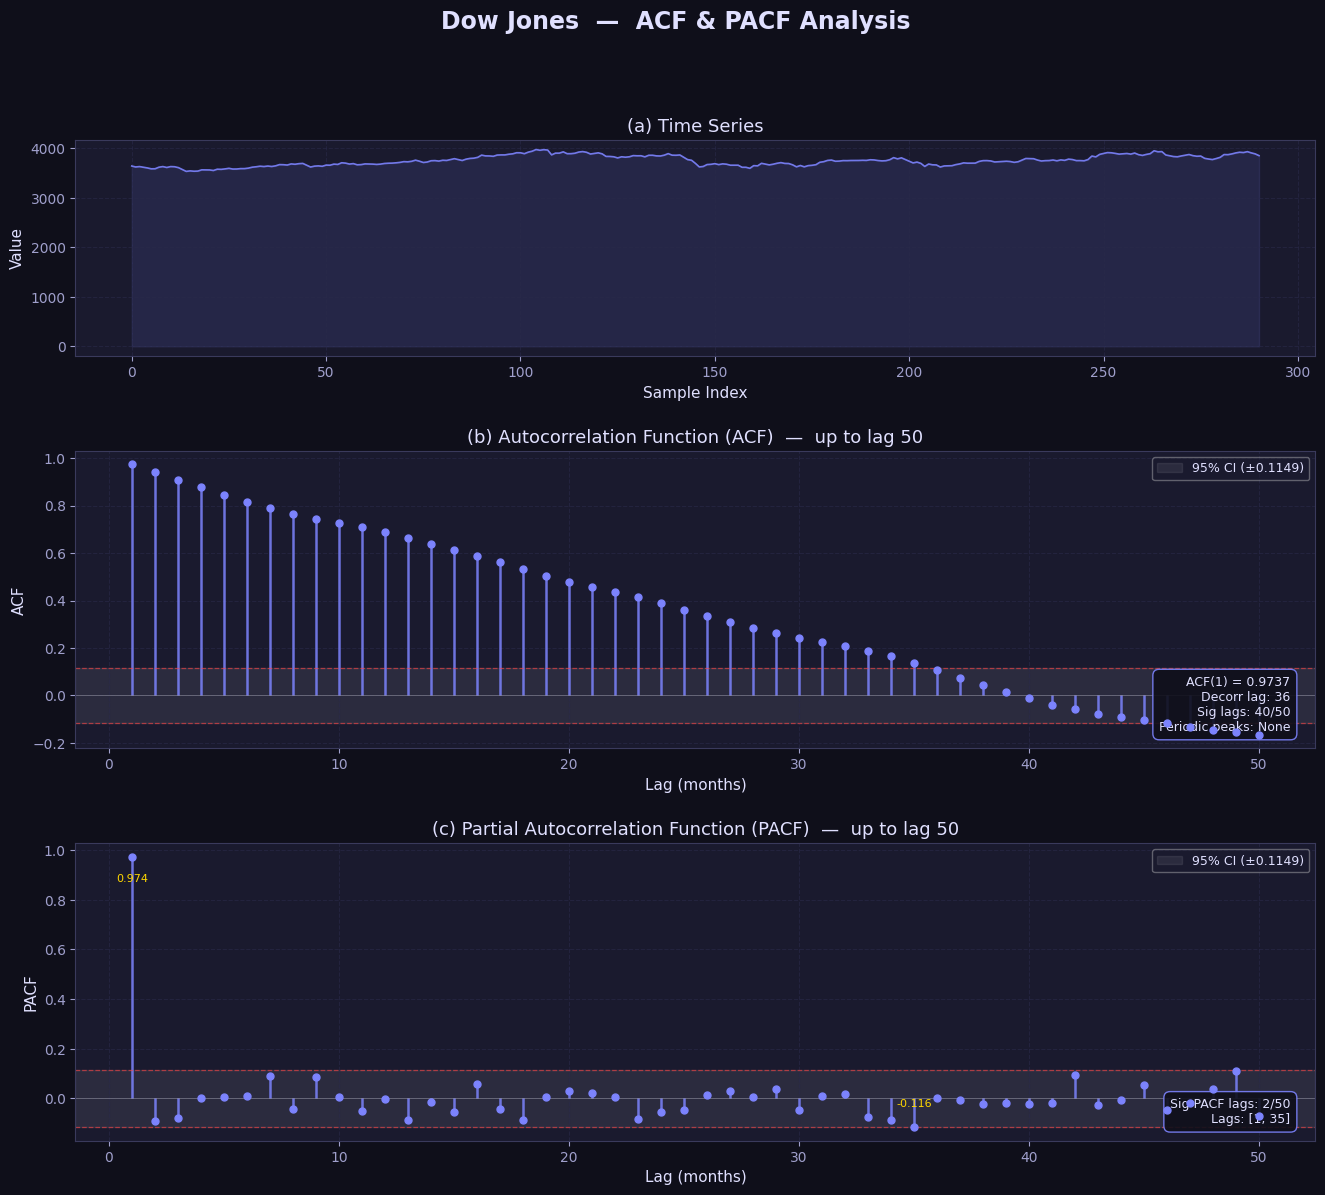

Saved → acf_pacf_dow_jones.png



In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — DOW JONES
# ══════════════════════════════════════════════════════════════════════════════
plot_acf_pacf('Dow Jones', datasets['Dow Jones'], 'acf_pacf_dow_jones')

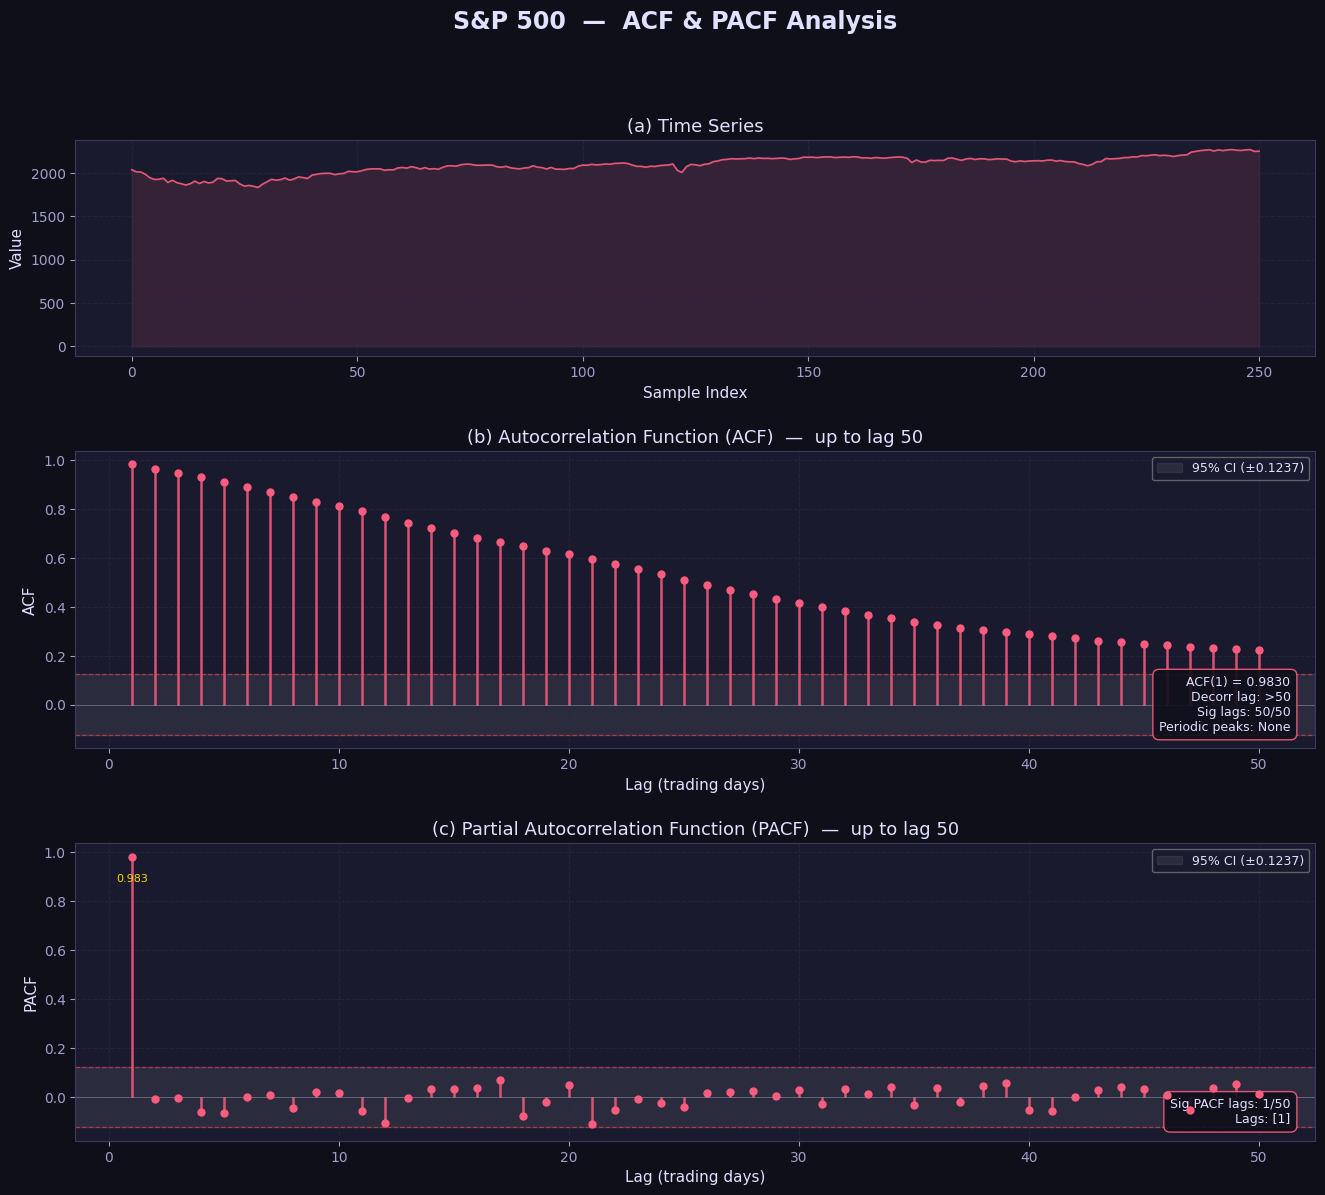

Saved → acf_pacf_sp500.png



In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — S&P 500
# ══════════════════════════════════════════════════════════════════════════════
plot_acf_pacf('S&P 500', datasets['S&P 500'], 'acf_pacf_sp500')

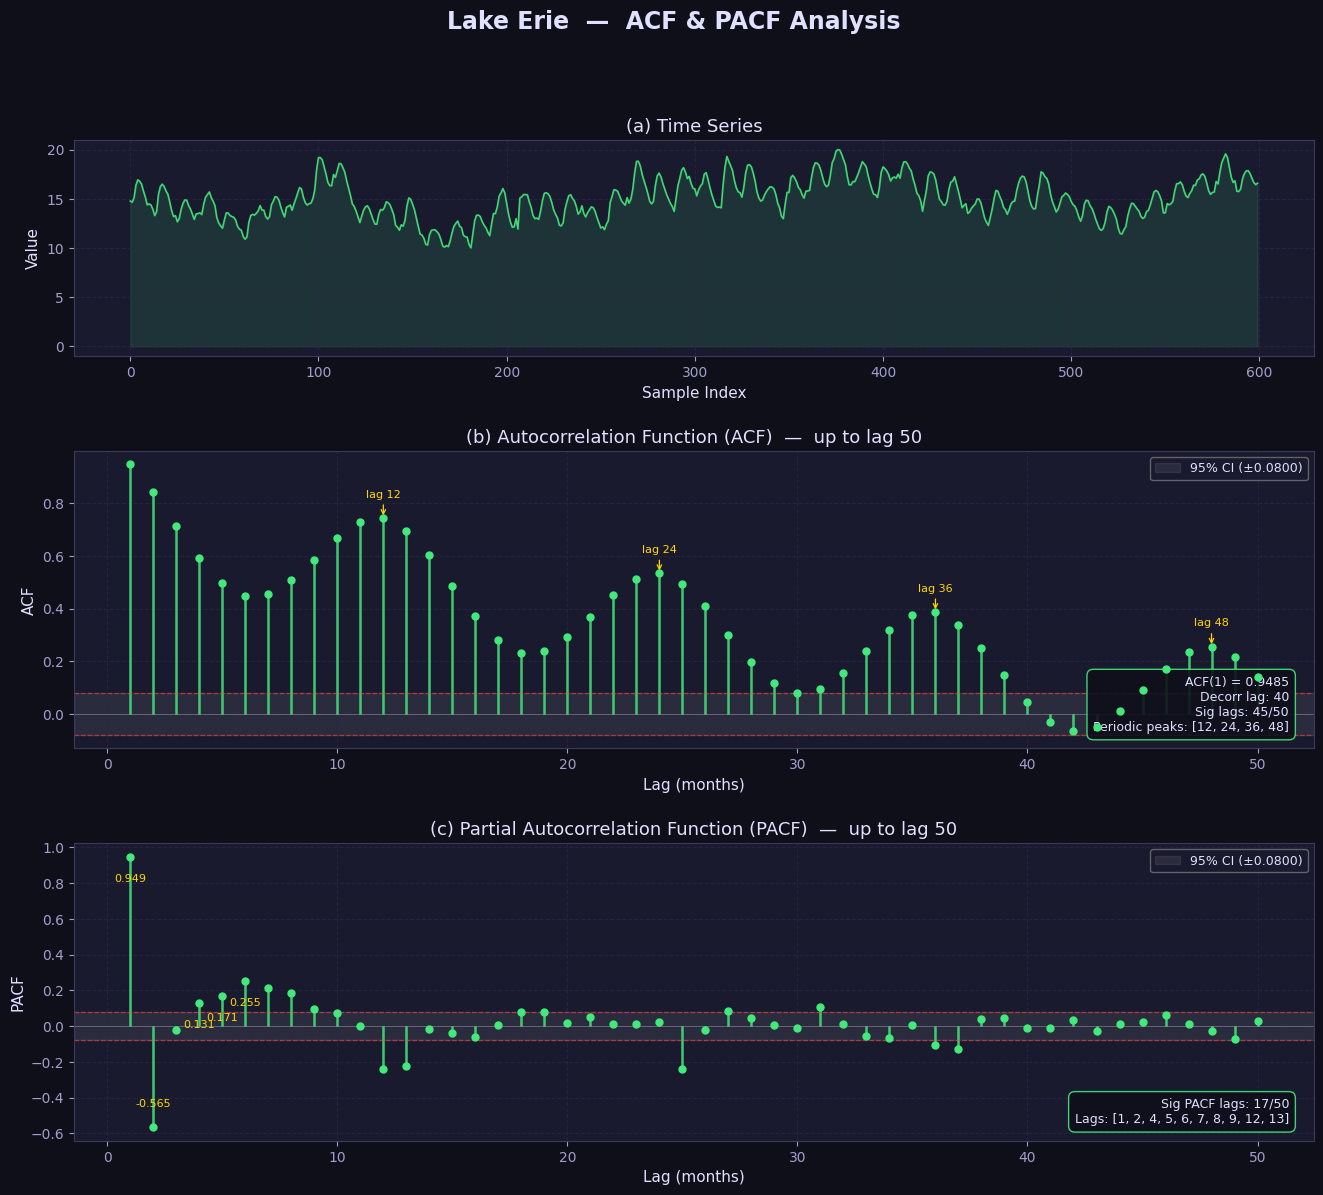

Saved → acf_pacf_lake_erie.png



In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 3 — LAKE ERIE
# ══════════════════════════════════════════════════════════════════════════════
plot_acf_pacf('Lake Erie', datasets['Lake Erie'], 'acf_pacf_lake_erie')

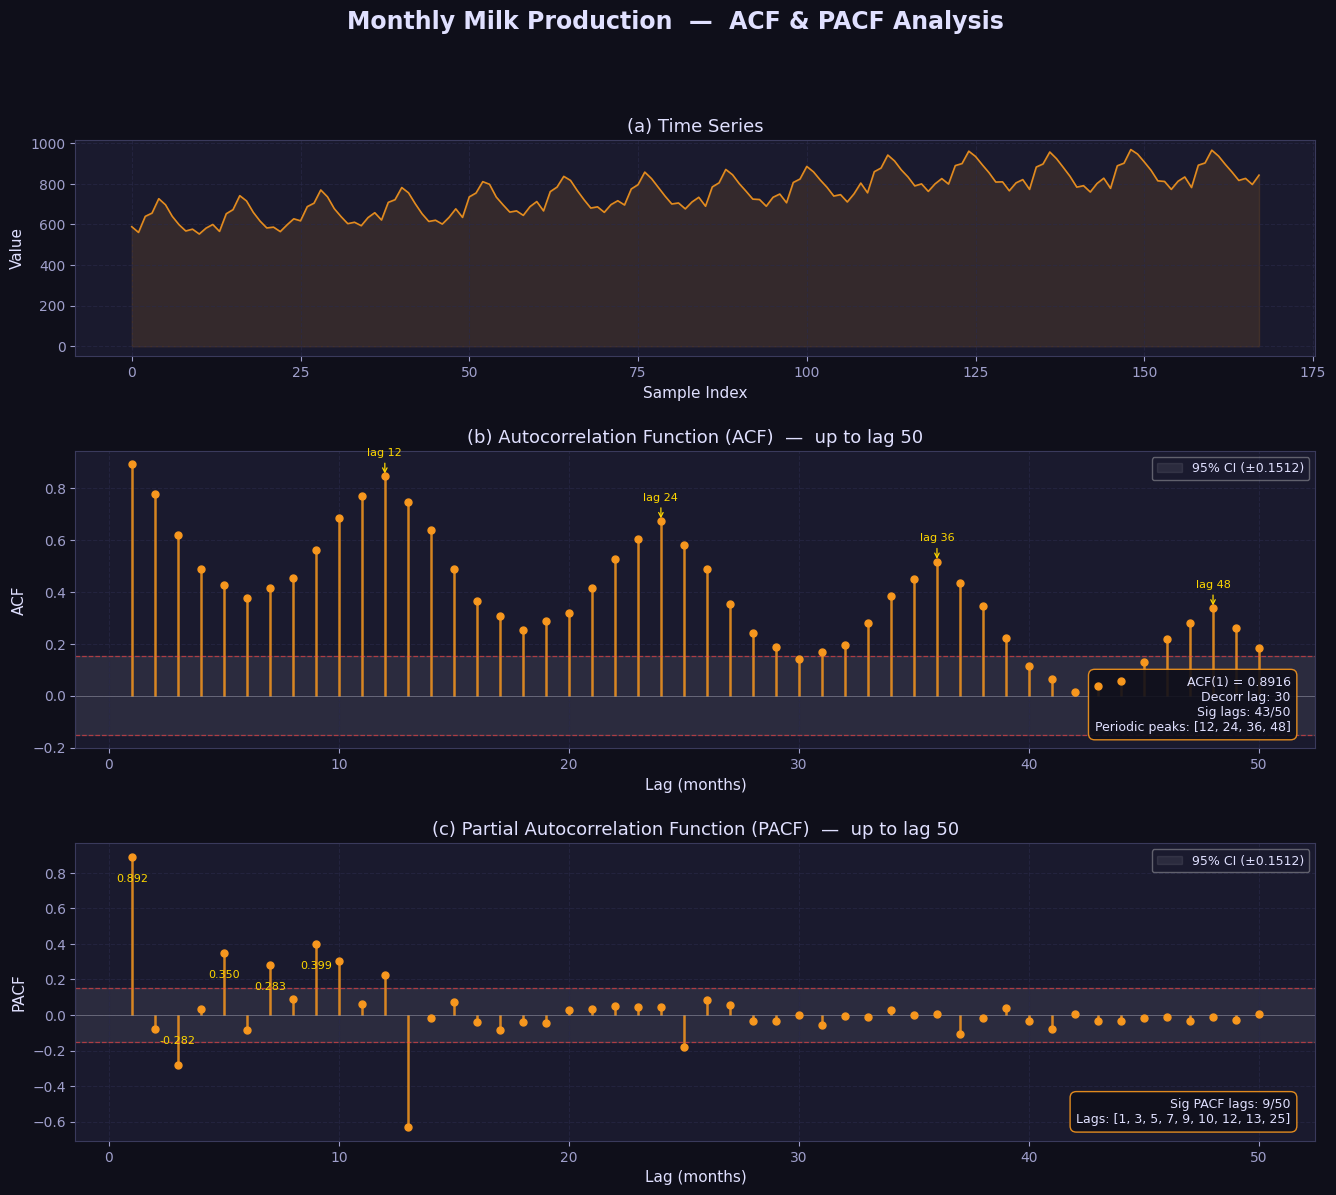

Saved → acf_pacf_milk_production.png



In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 4 — MONTHLY MILK PRODUCTION
# ══════════════════════════════════════════════════════════════════════════════
plot_acf_pacf('Monthly Milk Production', datasets['Monthly Milk Production'],
              'acf_pacf_milk_production')

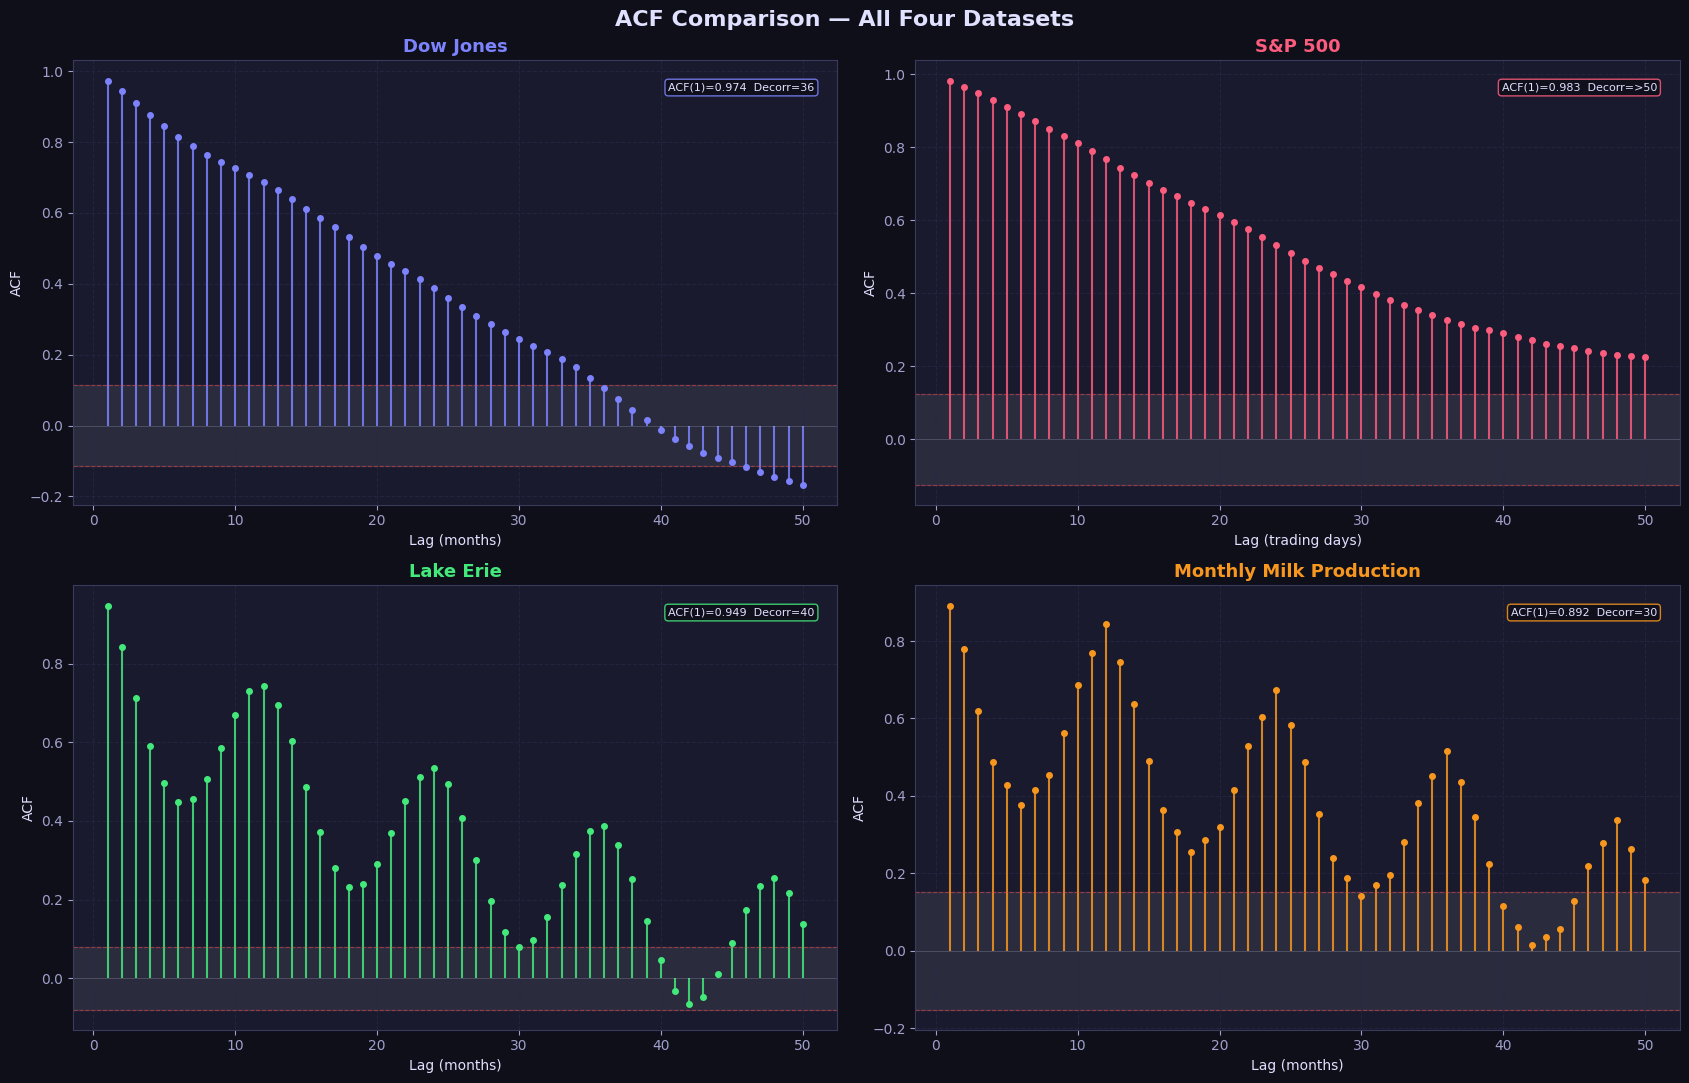

Saved → acf_all_comparison.png


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# COMBINED — 4-panel ACF comparison
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(17, 11))
fig.suptitle('ACF Comparison — All Four Datasets', fontsize=16,
             fontweight='bold', color='#e0e0ff')

for ax, (name, meta) in zip(axes.flatten(), datasets.items()):
    c     = meta['corr']
    color = PALETTE[name]
    pu    = meta['period_unit']

    markerline, stemlines, baseline = ax.stem(
        c['lags'][1:], c['acf_vals'][1:], linefmt='-', markerfmt='o', basefmt=' ')
    plt.setp(stemlines, color=color, linewidth=1.5, alpha=0.85)
    plt.setp(markerline, color=color, markersize=4, zorder=5)

    ax.axhspan(-c['sig_threshold'], c['sig_threshold'],
               color='white', alpha=0.08)
    ax.axhline(c['sig_threshold'],  color='#ff4444', linestyle='--',
               linewidth=0.8, alpha=0.5)
    ax.axhline(-c['sig_threshold'], color='#ff4444', linestyle='--',
               linewidth=0.8, alpha=0.5)
    ax.axhline(0, color='white', linewidth=0.4, alpha=0.3)

    ax.set_title(name, fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel(f'Lag ({pu})', fontsize=10)
    ax.set_ylabel('ACF', fontsize=10)
    ax.grid(True)

    info = f'ACF(1)={c["acf_lag1"]:.3f}  Decorr={c["decorrelation_lag"] or ">50"}'
    ax.text(0.97, 0.95, info, transform=ax.transAxes,
            fontsize=8, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#0f0f1a',
                      edgecolor=color, alpha=0.85),
            color='#e0e0ff')

plt.tight_layout()
plt.savefig('acf_all_comparison.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved → acf_all_comparison.png')

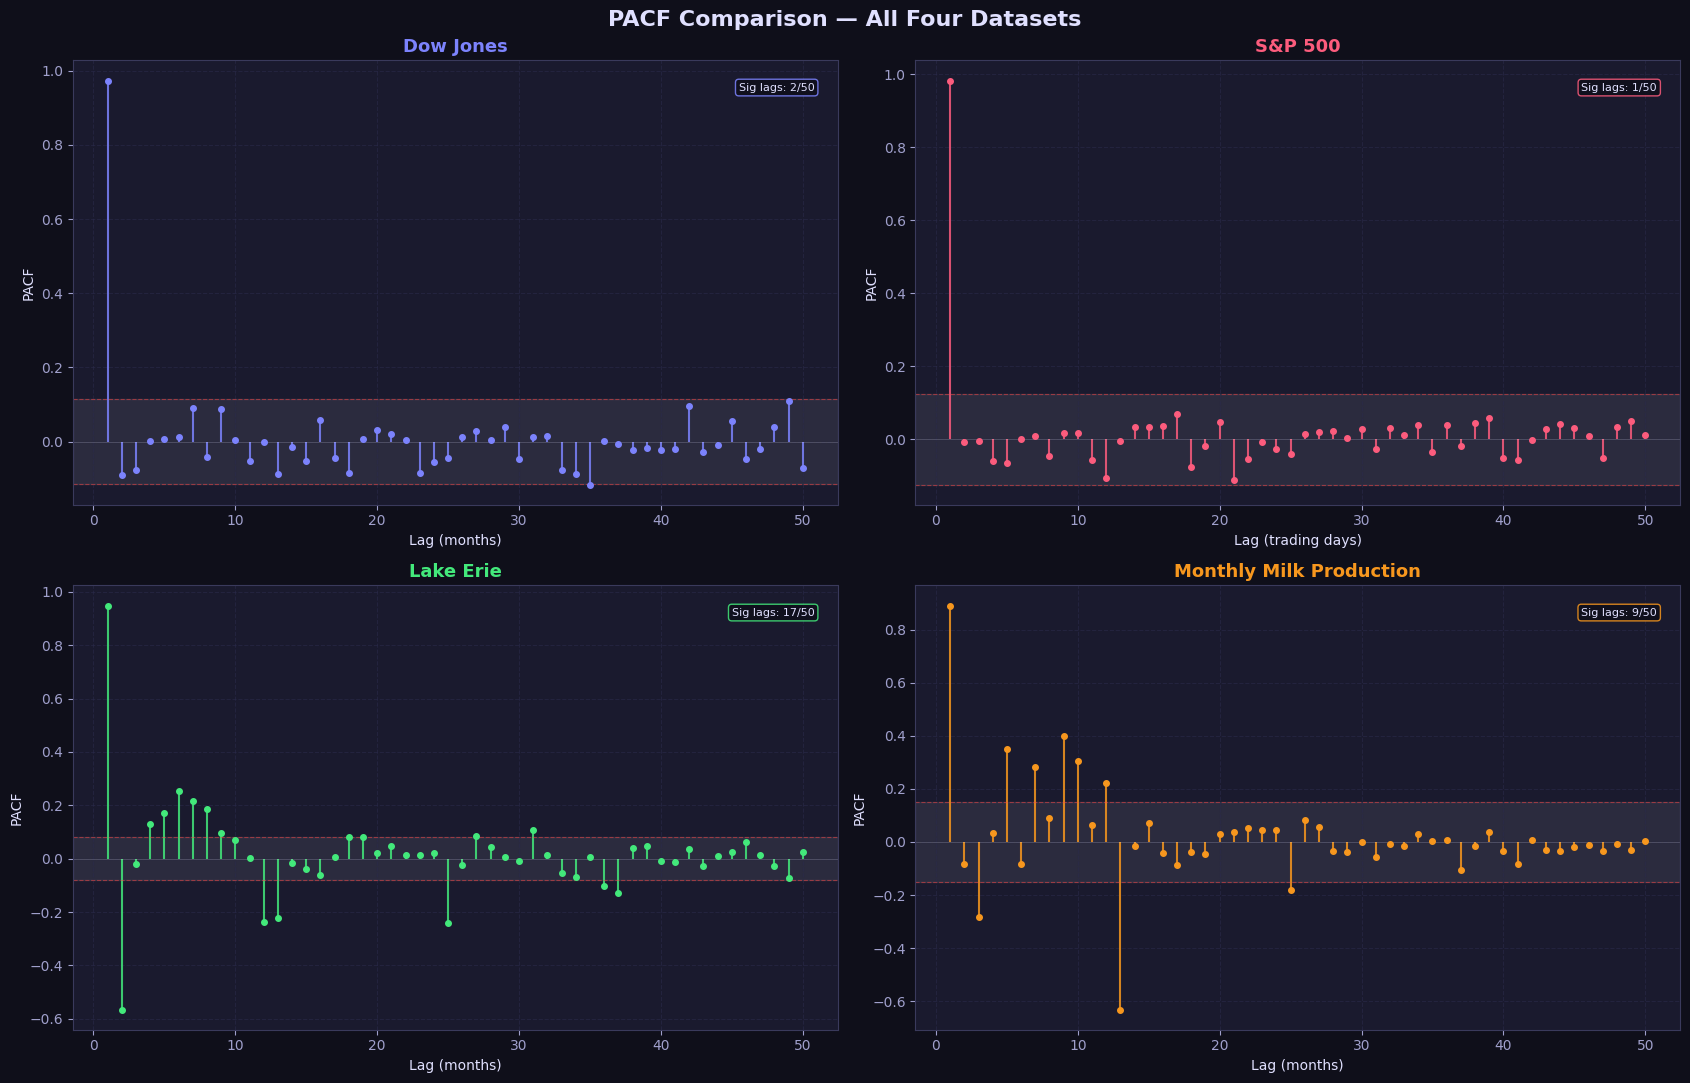

Saved → pacf_all_comparison.png


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# COMBINED — 4-panel PACF comparison
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(17, 11))
fig.suptitle('PACF Comparison — All Four Datasets', fontsize=16,
             fontweight='bold', color='#e0e0ff')

for ax, (name, meta) in zip(axes.flatten(), datasets.items()):
    c     = meta['corr']
    color = PALETTE[name]
    pu    = meta['period_unit']

    markerline, stemlines, baseline = ax.stem(
        c['lags'][1:], c['pacf_vals'][1:], linefmt='-', markerfmt='o', basefmt=' ')
    plt.setp(stemlines, color=color, linewidth=1.5, alpha=0.85)
    plt.setp(markerline, color=color, markersize=4, zorder=5)

    ax.axhspan(-c['sig_threshold'], c['sig_threshold'],
               color='white', alpha=0.08)
    ax.axhline(c['sig_threshold'],  color='#ff4444', linestyle='--',
               linewidth=0.8, alpha=0.5)
    ax.axhline(-c['sig_threshold'], color='#ff4444', linestyle='--',
               linewidth=0.8, alpha=0.5)
    ax.axhline(0, color='white', linewidth=0.4, alpha=0.3)

    ax.set_title(name, fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel(f'Lag ({pu})', fontsize=10)
    ax.set_ylabel('PACF', fontsize=10)
    ax.grid(True)

    info = f'Sig lags: {len(c["sig_pacf_lags"])}/{c["nlags"]}'
    ax.text(0.97, 0.95, info, transform=ax.transAxes,
            fontsize=8, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#0f0f1a',
                      edgecolor=color, alpha=0.85),
            color='#e0e0ff')

plt.tight_layout()
plt.savefig('pacf_all_comparison.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved → pacf_all_comparison.png')

In [13]:
# ── Cross-dataset summary table ───────────────────────────────────────────────
rows = []
for name, meta in datasets.items():
    c = meta['corr']
    rows.append({
        'Dataset':              name,
        'N':                    c['N'],
        'ACF(1)':               round(c['acf_lag1'], 6),
        'Decorr Lag':           c['decorrelation_lag'] if c['decorrelation_lag'] else f'>{c["nlags"]}',
        'ACF Energy':           round(c['acf_energy'], 4),
        'Sig ACF Lags':         len(c['sig_acf_lags']),
        'Sig PACF Lags':        len(c['sig_pacf_lags']),
        'Periodic Peaks':       str(c['periodic_lags'][:5]) if c['periodic_lags'] else 'None',
    })

summary_df = pd.DataFrame(rows).set_index('Dataset')
print('\n── Cross-Dataset Summary Table ──')
print(summary_df.to_string())
summary_df


── Cross-Dataset Summary Table ──
                           N    ACF(1) Decorr Lag  ACF Energy  Sig ACF Lags  Sig PACF Lags    Periodic Peaks
Dataset                                                                                                     
Dow Jones                291  0.973730         36     12.3200            40              2              None
S&P 500                  251  0.982968        >50     17.3464            50              1              None
Lake Erie                600  0.948525         40      9.1212            45             17  [12, 24, 36, 48]
Monthly Milk Production  168  0.891574         30     10.0826            43              9  [12, 24, 36, 48]


,N,ACF(1),Decorr Lag,ACF Energy,Sig ACF Lags,Sig PACF Lags,Periodic Peaks
Dataset,,,,,,,
Dow Jones,291,0.973730,36,12.3200,40,2,None
S&P 500,251,0.982968,>50,17.3464,50,1,None
Lake Erie,600,0.948525,40,9.1212,45,17,"[12, 24, 36, 48]"
Monthly Milk Production,168,0.891574,30,10.0826,43,9,"[12, 24, 36, 48]"


---

## Interpretation Summary

### Dow Jones (Monthly Closings)
- **ACF**: Slow linear decay — classic signature of a **non-stationary trend** or **unit root** process.
- **PACF**: Strong spike at lag 1, then cuts off → consistent with **AR(1)** or **random walk**.
- **Verdict**: Needs differencing before modelling. ARIMA(1,1,0) or ARIMA(0,1,1) likely appropriate.

### S&P 500 (Daily Opens)
- **ACF**: Very slow decay, all lags significant → **strong non-stationarity** / trending behaviour.
- **PACF**: Dominant lag-1 spike → underlying AR(1) structure after differencing.
- **Verdict**: Random-walk-like. Differencing required. Similar to Dow Jones but at daily cadence.

### Lake Erie (Monthly Levels)
- **ACF**: Slow decay with **periodic humps** — combination of trend + **12-month seasonality**.
- **PACF**: Multiple significant lags with peaks near seasonal multiples → **seasonal AR** component.
- **Verdict**: SARIMA model recommended. Clear 12-month periodicity overlaid on slow-decaying trend.

### Monthly Milk Production
- **ACF**: Oscillating pattern with **clear peaks at lags 12, 24, 36, 48** → textbook **seasonal autocorrelation**.
- **PACF**: Significant at lags 1, 2, and seasonal multiples → seasonal + short-term AR components.
- **Verdict**: Strongest seasonal signal. SARIMA(p,d,q)(P,D,Q)[12] is the natural model family.

In [ ]:
# ============================================================
# NOTEBOOK TIMER — END
# ============================================================
import time as _timer_module
_NOTEBOOK_END_TIME = _timer_module.time()
_NOTEBOOK_ELAPSED = _NOTEBOOK_END_TIME - _NOTEBOOK_START_TIME
_hours, _rem = divmod(_NOTEBOOK_ELAPSED, 3600)
_minutes, _seconds = divmod(_rem, 60)
print(f"\nTotal notebook execution time: {int(_hours)}h {int(_minutes)}m {_seconds:.2f}s")
print(f"Total seconds: {_NOTEBOOK_ELAPSED:.2f}")
